Num images: 70000, Num features (pixels): 784


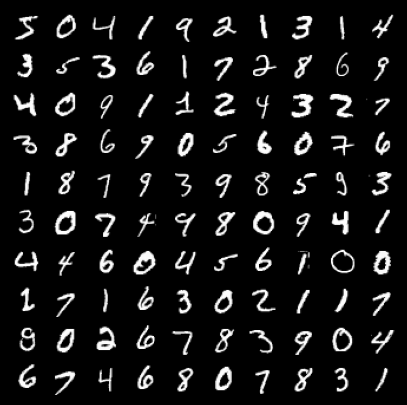

In [56]:
## prepare mnist data

# extract MNIST data from sklearn api
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', parser='pandas')
X, y = mnist["data"].to_numpy(), mnist["target"].to_numpy()
print(f"Num images: {X.shape[0]}, Num features (pixels): {X.shape[1]}")

# subset training / test sets
from sklearn.model_selection import train_test_split

# flatten image data
n_samples = len(X)
X = X.reshape((n_samples, -1))

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# reduce size of training set for speed
X_train_subset = X_train[:1000]
y_train_subset = y_train[:1000]

# reversing colours of digits
def dark_digit(X_array_component):
    X_dark_component = []
    for i in range(len(X_array_component)):
        dd = (X_array_component[i] - 273) * -1
        X_dark_component.append(dd)
    return X_dark_component

X_train_dark = dark_digit(X_train_subset)
X_test_dark  = dark_digit(X_test)

# display sample
import matplotlib.pyplot as plt
plt.style.use('dark_background')
fig, axis = plt.subplots(10, 10, figsize=(5, 5))
labels = ""
for i, ax in enumerate(axis.flat):
    example_digit = X_train_dark[i].reshape(28, 28)
    labels = labels + f"{y[i]}, "
    ax.imshow(example_digit, cmap='binary')
    ax.axis("off")

6


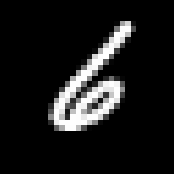

In [57]:
i = 999
print(y_train_subset[i])
dd = X_train_dark[i].reshape(28, 28)
plt.figure(figsize=(2,2))
plt.imshow(dd, cmap='binary')
plt.axis("off")
plt.show()

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler # data cleanup
from sklearn.svm import SVC # model

# prepare pipeline for grid search
classifier_pipeline = Pipeline([
    ("preprocessing", StandardScaler()),
    ("model", SVC(C=1)), # place holder model
])

# grid search
param_search = [
    {
        "model": [SVC()],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": [1e-2, 1e-3, 1e-4],
        "model__C": [10, 100, 1000]
    },
]
clf = GridSearchCV(classifier_pipeline, param_search, cv=5, scoring='f1_macro')
clf.fit(X_train_dark, y_train_subset)

# extract parameters
best_p = clf.best_params_
best_c = best_p['model__C']
best_gamma = best_p['model__gamma']
best_kernel = best_p['model__kernel']
print(f"Best Parameters: \n{best_p}")

Best Parameters: 
{'model': SVC(), 'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'linear'}


0.878
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1373
           1       0.92      0.97      0.94      1569
           2       0.86      0.89      0.88      1430
           3       0.88      0.79      0.84      1413
           4       0.88      0.88      0.88      1376
           5       0.79      0.83      0.81      1253
           6       0.93      0.90      0.91      1339
           7       0.88      0.90      0.89      1483
           8       0.86      0.80      0.83      1365
           9       0.83      0.83      0.83      1399

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000



<Figure size 620x440 with 0 Axes>

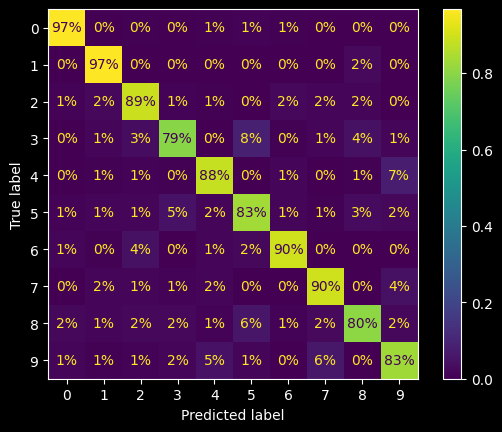

In [59]:
svc_classifier_pipeline = Pipeline([
    ("preprocessing", StandardScaler()),
    ("model", SVC(kernel=best_kernel,C=best_c, gamma=best_gamma))
])

# fit pipeline to training data
svc_classifier_pipeline.fit(X_train_dark, y_train_subset)

# predict against the test data
y_pred = svc_classifier_pipeline.predict(X_test_dark)
score = svc_classifier_pipeline.score(X_test_dark, y_test)
print(f"{score:.3f}")

# final report & confusion matrix
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(6.2, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", values_format=".0%"
    )
plt.show()